In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics as st


                                    CORRELATION AND LINEAL REGRESSION

INTRODUCTION

In statistics , not all relationships are created equal. Correlation is a symmetrical tool, regardless which variable is mentioned first, and describes how tightly both variables cluster around hidden line. It measures the strength and direction of their bond. However, Lineal Regression goes step further, by providing a "tool" to estimate one based to another. It treats one variable as the cause (independent) and the other one as an effect (dependent), and explains how much the "effect" changes for every unit of the "cause"

If X and Y are two variables , in Correlation they are interchangeable. In Regression swapping X and Y - the result will be completely different model.

SUMMARY COMPARISON:

- CORRELATION:
- -Measure strength of association
- -X and Y are symmetrical.
- -The result is always in range [-1 ; 1]
-
- LINEAL REGRESSION:
- -Model/Predict the relationship
- -Y depends on X (directional)
- -The result could be any value that represents rate of change


PART 1: PEARSON CORRELATION

Let's start with one simple example to illustrate how Pearson correlation works using two variables.
We have data about the IQ test of students, avd the result of statistic exam:

In [2]:
IQ_Test = [595, 520, 715, 405, 680, 490, 565, 580, 615, 435, 440, 515, 380, 510, 565]

In [3]:
Exam_results = [68, 55, 65, 42, 64, 45, 56, 59, 56, 42, 38, 50, 37, 42, 53]

In [4]:
# Data source:Красимир Калинов - Статистически методи в поведенческите и социалните науки

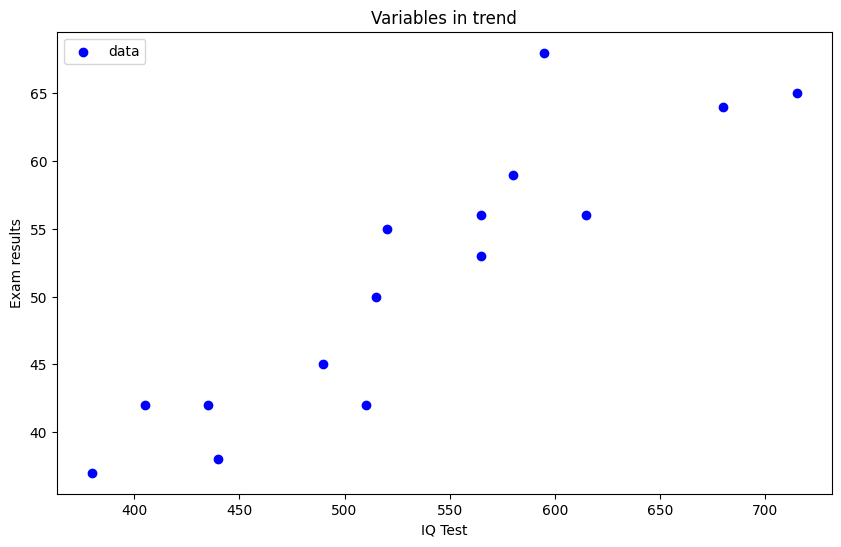

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(IQ_Test, Exam_results, c='b', label='data')
plt.xlabel("IQ Test")
plt.ylabel("Exam results")
plt.title('Variables in trend')
plt.legend(loc='upper left')
plt.show()

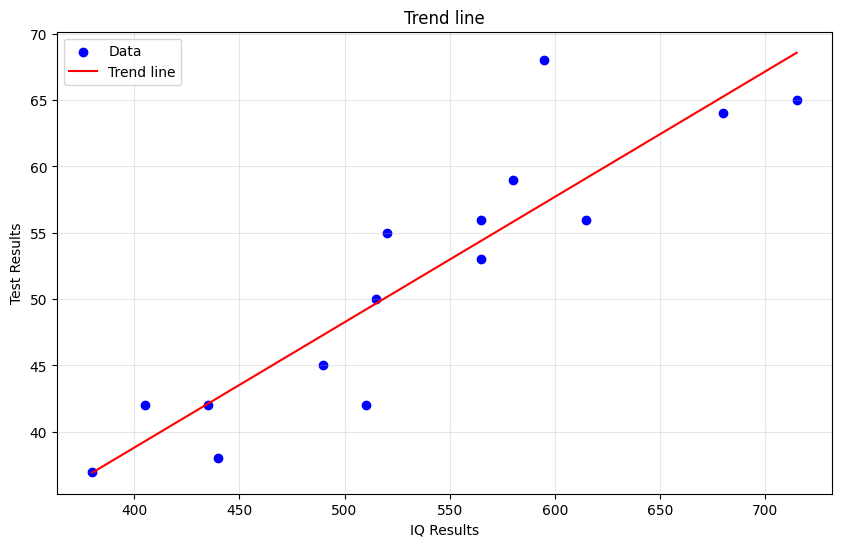

In [6]:


x = IQ_Test
y = Exam_results
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Data')

plt.plot(sorted(x), p(sorted(x)), color='red', label='Trend line')

plt.title('Trend line')
plt.xlabel('IQ Results')
plt.ylabel('Test Results')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.show()

 The charts above shows that variables "x", and "y" clearly described uptrend direction.
 The directional joint move of two variables is mesured by COVARIANCE of "x" and "y", or cov(x, y).

$\bar{x}$ - Arithmetic mean

$\bar{x} = \frac{1}{n}\sum_{x=1}^{n} x_i$

$cov(x, y) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$

- When both variables increase - the covariance is positive
- When one variable increases and the other decreases - the covariance is negative
- If both variables do not vary - the covariance is zero "0".

In [7]:
# Covariance of IQ test and Exam results #

In [8]:
np.cov(IQ_Test, Exam_results)

array([[9318.57142857,  880.85714286],
       [ 880.85714286,  102.12380952]])

In [42]:
covariance_IQ_Exam = np.cov(IQ_Test, Exam_results)

Standard deviation:
- the differences between $x_i$ and $\bar{x}$ , $(x_i - \bar{x})$ is positive or negative, their sum is up to "0"

- when we square them (all positive) - $S^2(x) = \frac{1}{n-1}\sum_{x=1}^{n}(x_i - \bar{x})^2$

- Standard deviation - $S(x) = \sqrt{S^2(x)}$

$p_i = \frac{(x_i - \bar{x})}{S_x} \frac{(y_i - \bar{y})}{S_y}$, divided by standard deviations, we "normalize" them.

$p = \frac{1}{n}\sum{p_i} = \frac{cov(x, y)}{S_xS_y}$
-"p" - Pearson correlation coefficient

In [10]:
stdev_IQ_test = st.stdev(IQ_Test)
stdev_Exam_results = st.stdev(Exam_results)

In [11]:
stdev_IQ_test

96.53274795928803

In [12]:
stdev_Exam_results

10.105632564258881

In [13]:
#Let's continue with our example and put two variables list in matrix

In [14]:
matrix = [x, y]

In [15]:
#Transposition of matrix .

In [16]:
transposed_matrix = [list(row) for row in zip(*matrix)]

In [17]:
labels=["IQ Test", "Exam Results"]
pd.DataFrame(transposed_matrix, columns=labels)

,IQ Test,Exam Results
0,595,68
1,520,55
2,715,65
3,405,42
4,680,64
5,490,45
6,565,56
7,580,59
8,615,56
9,435,42


In [18]:
P_IQ_Exam = covariance_IQ_Exam/  (stdev_IQ_test * stdev_Exam_results)

In [19]:
P_IQ_Exam

array([[9.55237066, 0.9029575 ],
       [0.9029575 , 0.10468606]])

In [20]:
st.correlation(IQ_Test, Exam_results)

0.9029574959390204

In [21]:
np.corrcoef(IQ_Test, Exam_results)


array([[1.       , 0.9029575],
       [0.9029575, 1.       ]])

In [51]:
print(f"Pearson coefficient of correlation is : {np.corrcoef(IQ_Test, Exam_results)[0][1]:.4f}, positive and strong (close to 1) ")

Pearson coefficient of correlation is : 0.9030, positive and strong (close to 1) 


In [22]:
# Function for multiple usage with different data for two variables, and  visualization

In [33]:
def Data_frame(var_1:list,var_2:list):
    array = [var_1, list(var_2)]
    transposd_array = [list(row) for row in zip(*array)]
    labels = [ input("Enter lable"), input("Enter lable") ]
    df = pd.DataFrame(transposd_array, columns=labels)
    return df

def Pearson_correlation(var_1:list,var_2:list):
    return st.correlation(var_1, var_2)

def plot_correlated_variables(var_1:list,var_2:list):
    x = var_1
    y = var_2
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='purple', label='Data')
    plt.plot(sorted(x), p(sorted(x)), color='blue', label='Trend line')
    plt.title('Pearson Correlation with a trend line')
    plt.xlabel('IQ Results')
    plt.ylabel('Exam Results')
    plt.grid(True, alpha=0.5)
    plt.legend(loc='upper left')
    return plt.show()





In [34]:
Data_frame(IQ_Test, Exam_results)

,IQ Test,Exam Results
0,595,68
1,520,55
2,715,65
3,405,42
4,680,64
5,490,45
6,565,56
7,580,59
8,615,56
9,435,42


In [35]:
Pearson_correlation(IQ_Test, Exam_results)

0.9029574959390204

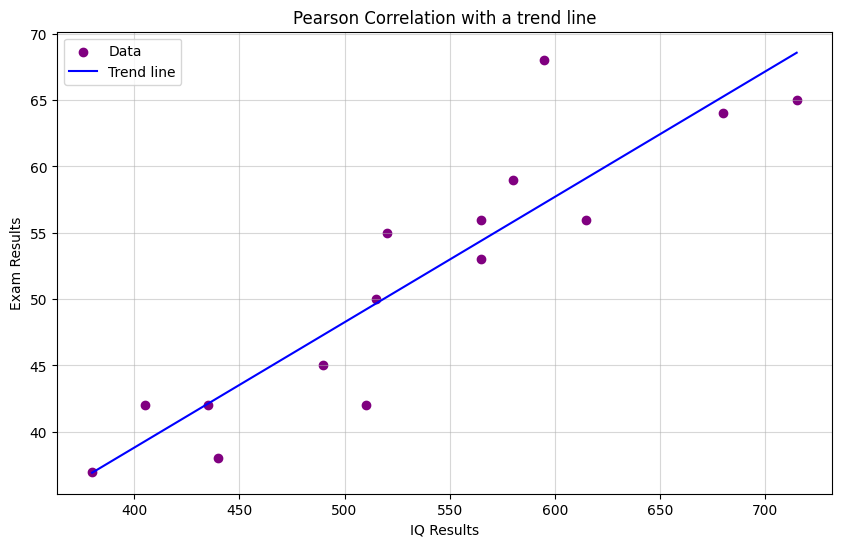

In [37]:
plot_correlated_variables(IQ_Test, Exam_results)

  PART 2: SIMPLE LINEAR REGRESSION

The Concept: From Association to Prediction
While correlation tells us how much
 and
 move together, Regression allows us to predict
 (the dependent variable) based on
 (the independent variable).
We are looking for the equation of the "Best Fit" line:

$Y = \beta_0 + \beta_1X + \varepsilon$
- $\beta_1$ (slope) - How much form previous example Exam Results increases for evry one point of IQ Test increase.
- $\beta_0$ (intercept) - The predicted value of Exam Results, if IQ Test were "0"
- $\varepsilon$ - stochastic part of the model

To find the line that minimizes the distance between the data points and the line (Ordinary Least Squares), we calculate:

Slope:
- $\beta_1 = \frac{cov(x, y}{var(x)}$

Intercept:
- $\beta_0 = \bar{Y} - \beta_1\bar{X}$

In [ ]:
# Calculating means of both IQ_Test and Exam_Results
mean_iq = np.mean(IQ_Test)
mean_exam = np.mean(Exam_results)

In [46]:

# Calculating b1 (slope)
# Using [0,1] from  covariation matrix and variation of X
var_iq = np.var(IQ_Test, ddof=1)
#cov_iq_exam = np.cov(IQ_Test, Exam_results)[0, 1], we already defined it as covariance_IQ_Exam = np.cov(IQ_Test, Exam_results) form previous example
covariance_IQ_Exam = covariance_IQ_Exam[0, 1]

b1 = covariance_IQ_Exam / var_iq
b0 = mean_exam - (b1 * mean_iq)

print(f"Coefficient b1 (Slope): {b1:.4f}")
print(f"Coefficient b0 (Intercept): {b0:.4f}")

Coefficient b1 (Slope): 0.0945
Coefficient b0 (Intercept): 0.9892
